In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
speed = np.arange(0, 100+1)


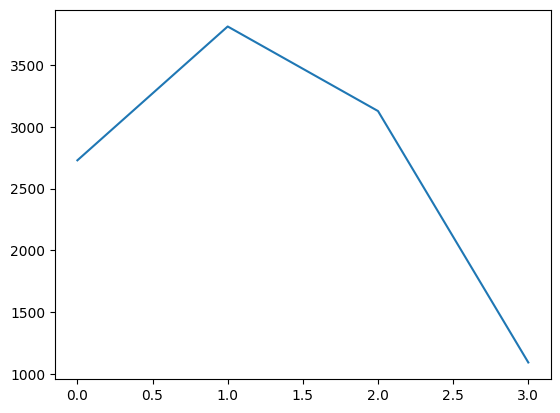

In [118]:
alpha=84
research = np.arange(0, 100+1-alpha)
scale = 100 - research - alpha
profit = 200_000 * np.log(1 + research) / np.log(1 + 100) * 7 / 100 * (scale) * 0.9 - (research + scale+alpha) / 100 * 50000
profit = profit[profit>0]
plt.plot(profit)
# plt.axvline(np.argmax(profit), color='red')
plt.show()

In [108]:
research + scale+alpha

array([100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100])

In [82]:
X, Y = np.meshgrid(speed, research)

In [83]:
Z = 100 - X - Y

In [84]:
mask = Z >= 0

In [85]:
X[mask] = 0
Y[mask] = 0
Z[mask] = 0

In [86]:
profit = 200_000 * np.log(1 + Y - X) / np.log(1 + 100) * 7 / 100 * Z * (0.1 + X * 0.8/100) - (X + Y + Z) / 100 * 50000

/var/folders/sn/lj91sdfx3kn8_bc114w6rmg40000gn/T/ipykernel_41294/208412407.py:1: RuntimeWarning: divide by zero encountered in log
  profit = 200_000 * np.log(1 + Y - X) / np.log(1 + 100) * 7 / 100 * Z * (0.1 + X * 0.8/100) - (X + Y + Z) / 100 * 50000
/var/folders/sn/lj91sdfx3kn8_bc114w6rmg40000gn/T/ipykernel_41294/208412407.py:1: RuntimeWarning: invalid value encountered in log
  profit = 200_000 * np.log(1 + Y - X) / np.log(1 + 100) * 7 / 100 * Z * (0.1 + X * 0.8/100) - (X + Y + Z) / 100 * 50000


In [87]:
np.nanargmax(profit)

np.int64(5101)

In [88]:
X[np.nanargmax(profit)], Y[np.nanargmax(profit)], Z[np.nanargmax(profit)]

IndexError: index 5101 is out of bounds for axis 0 with size 101

In [89]:
profit.shape

(101, 101)

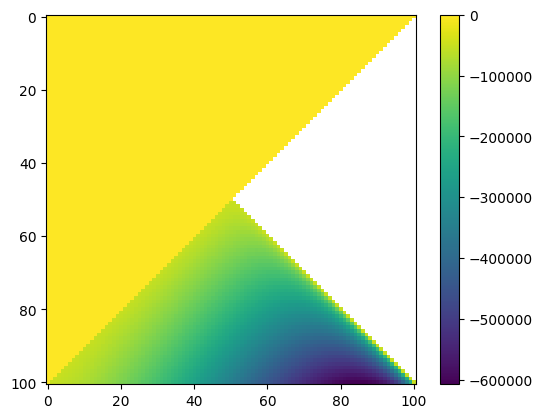

In [91]:
plt.imshow(profit)
plt.colorbar()

In [499]:
multipliers = np.linspace(0.1, 0.9, 500)
N = 1000
speed_distriubution = np.ones(N)/N

def gaussian(x, mu, sig):
    return (
        1.0 / (np.sqrt(2.0 * np.pi) * sig) * np.exp(-np.power((x - mu) / sig, 2.0) / 2)
    )

spread = 3

def add_guassian_to_distribution(previous_distribution, value, spread, multiplier):
    N = len(previous_distribution)
    percentages = np.linspace(0, 100, N)
    speed_distriubution_normal = gaussian(percentages, value, spread)
    previous_distribution += speed_distriubution_normal / speed_distriubution_normal.sum() * multiplier
    return previous_distribution/previous_distribution.sum()


def speed_multiplier(share, speed_distriubution3):
    N = 1000
    return speed_distriubution3[:int(share/100*N)].sum() * 0.8 + 0.1

def calculate_optimal(multiplier_factor, speed_distriubution2):
    speed_distriubution4 = speed_distriubution.copy()
    difference = np.inf
    threshold = 1
    multiplier = 1
    prev_best_speed = 0  # Keep this outside

    while difference > threshold:
        max_profit = 0   # MUST reset every iteration
        best_speed = 0   # MUST reset every iteration
        best_research = 0
        best_scale = 0
        
        for speed in range(85):
            for research in range(30):
                scale = 100 - research - speed
                
                # Assuming speed_multiplier(speed) calculates Expected Value based on the current speed_distriubution
                profit = (200_000 * np.log(1 + research) / np.log(1 + 100) 
                        * (7 / 100 * scale) 
                        * speed_multiplier(speed, speed_distriubution4) 
                        - 50000) # Since budget is always 100%, cost is static 50k
                
                if profit > max_profit:
                    max_profit = profit
                    best_research = research
                    best_scale = scale
                    best_speed = speed
                    
        difference = abs(best_speed - prev_best_speed) # Prevent negative difference breakouts
        prev_best_speed = best_speed
        
        multiplier *= multiplier_factor
        speed_distriubution4 = add_guassian_to_distribution(speed_distriubution4, best_speed, 3, multiplier)
    return best_speed, max_profit, best_research, best_scale

    # print(f"Optimal Speed converges at: {best_speed}")
    # print(f"Optimal profit converges at: {max_profit}")
    # print(f"Optimal research converges at: {best_research}")
    # print(f"Optimal scale converges at: {best_scale}")

    # print(speed_multiplier(best_speed))

max_profits = []
best_speeds = []
for multiplier_factor in multipliers:
    best_speed, max_profit, best_research, best_scale = calculate_optimal(multiplier_factor, speed_distriubution)
    max_profits.append(max_profit)
    best_speeds.append(best_speed)
                

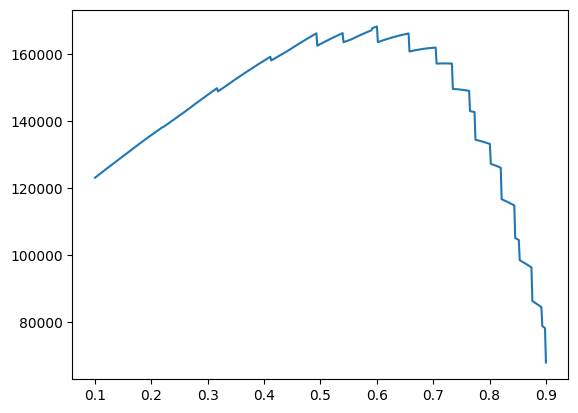

In [502]:
plt.plot(multipliers, max_profits)

1.0000000000000004


<BarContainer object of 1000 artists>

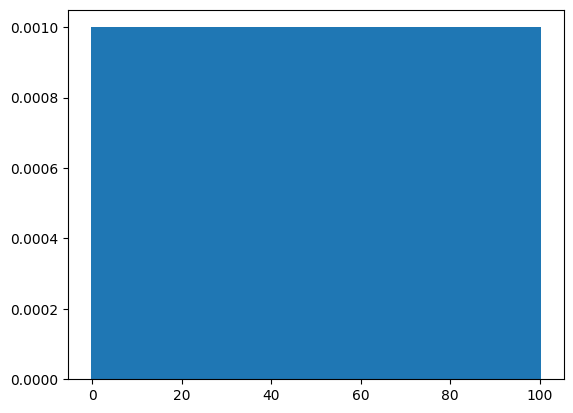

In [498]:
print(speed_distriubution.sum())
plt.bar(percentages, speed_distriubution)